<a href="https://colab.research.google.com/github/wayhome/101colab/blob/main/PairsTrading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 为 matplotlib 添加中文支持
!apt -qy install fonts-noto-cjk
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_cjk = fm.FontProperties(fname=r'/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
plt.rcParams['font.family'] = font_cjk.get_name()
fm.fontManager.addfont(font_cjk.get_file())
matplotlib.rc('font', family=font_cjk.get_name())

Reading package lists...
Building dependency tree...
Reading state information...
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 4s (16.4 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import pathlib
import shutil

root_path = pathlib.Path("/content/drive/MyDrive/colab")
cache_path = root_path / "cache"

if not root_path.exists():
  from google.colab import drive
  drive.mount('/content/drive')

# 替换系统的默认缓存路径为指定的 cache_path, 基于 google drive 复用缓存
origin_cache_path = pathlib.Path.home() / ".cache"
if origin_cache_path.exists():
    if origin_cache_path.is_symlink():
        pass
    else:
        shutil.rmtree(origin_cache_path)
        origin_cache_path.symlink_to(cache_path)

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# generate random walk series
np.random.seed(112)
F = [50]
for i in range(252):
    F.append(F[i] + np.random.randn())
F = np.array(F)

# generate price series
P_a = F + np.random.randn(len(F))
P_b = F + np.random.randn(len(F))

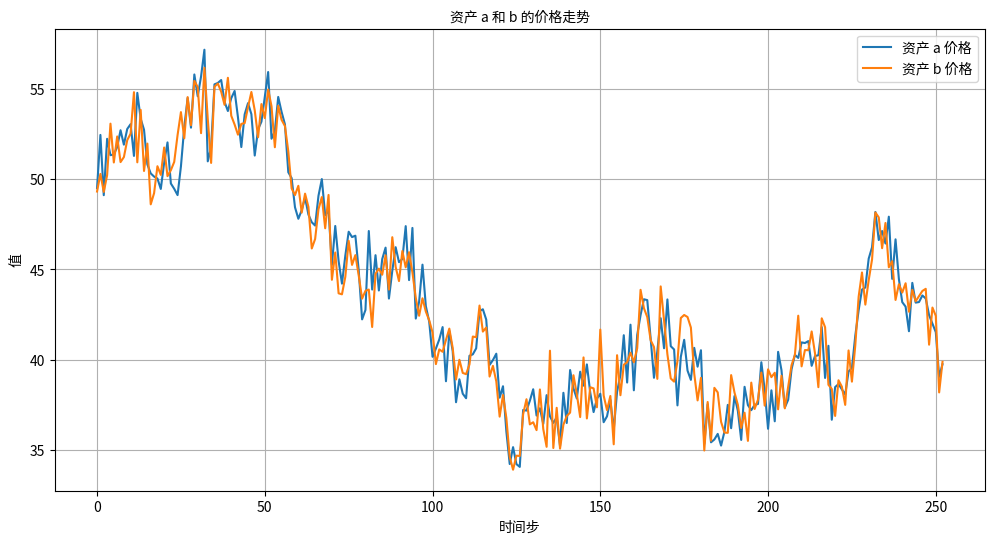

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(P_a, label='资产 a 价格')
plt.plot(P_b, label='资产 b 价格')
plt.title('资产 a 和 b 的价格走势', fontproperties=font_cjk)
plt.xlabel('时间步', fontproperties=font_cjk)
plt.ylabel('值', fontproperties=font_cjk)
plt.legend(prop=font_cjk)
plt.grid(True)
plt.show()

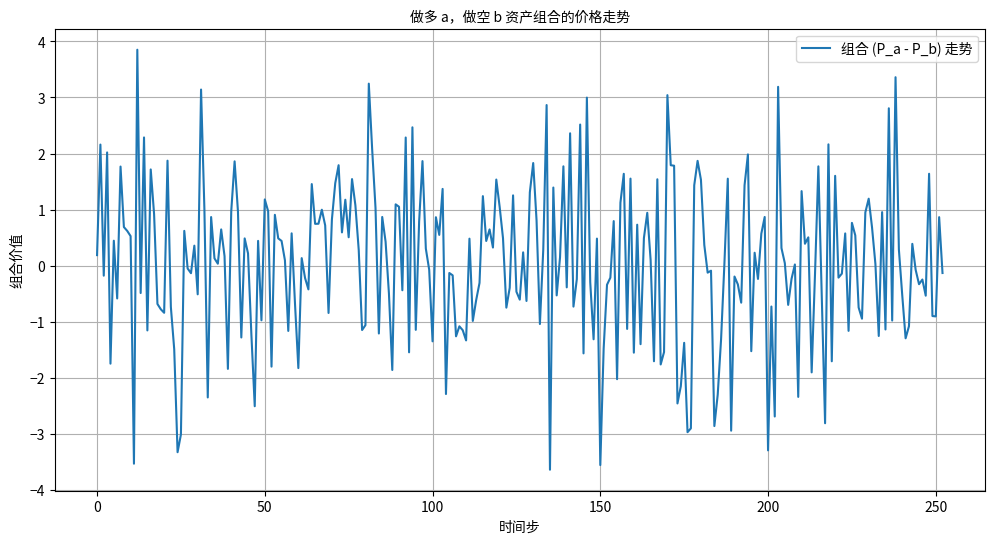

In [8]:
import matplotlib.pyplot as plt

# 创建做多 P_a，做空 P_b 的资产组合
portfolio_ab = P_a - P_b

plt.figure(figsize=(12, 6))
plt.plot(portfolio_ab, label='组合 (P_a - P_b) 走势')
plt.title('做多 a，做空 b 资产组合的价格走势', fontproperties=font_cjk)
plt.xlabel('时间步', fontproperties=font_cjk)
plt.ylabel('组合价值', fontproperties=font_cjk)
plt.legend(prop=font_cjk)
plt.grid(True)
plt.show()